# Notebook 02 — Exploratory Data Analysis
**Project: Coastal Property Catastrophe Loss Model**

Explore the NFIP claims dataset to understand loss distributions, key risk drivers, and patterns that will inform our frequency/severity models.

## Key Questions
1. How do claim rates and severity vary by flood zone?
2. What is the effect of hurricane category on claim severity?
3. How does construction age / post-FIRM indicator affect losses?
4. What is the annual loss pattern — which years had the worst losses?
5. Are there coverage-to-loss relationships we should model?

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('../data/raw')

# Load enriched claims from notebook 01
claims = pd.read_parquet(DATA_DIR / 'nfip_claims_enriched.parquet')
claims_pos = claims[claims['amountPaidOnBuildingClaim'].fillna(0) > 0].copy()

print(f'Total records:     {len(claims):,}')
print(f'Records w/ claim:  {len(claims_pos):,} ({len(claims_pos)/len(claims):.1%})')
print(f'Year range:        {claims["yearOfLoss"].min():.0f} – {claims["yearOfLoss"].max():.0f}')

Total records:     336,662
Records w/ claim:  258,897 (76.9%)
Year range:        2000 – 2023


## 1. Claim Rate by Flood Zone

zone_stats shape: (5, 5)
                     total_records  claim_rate      avg_loss
flood_zone_category                                         
coastal_high_risk             5565    0.925966  52439.804562
high_risk                    98150    0.953632  51788.752627
moderate_risk                29451    0.937557  50043.381518
minimal_risk                  1377    0.941903  52495.402914
unknown                     137706    0.953016  42994.395687

Flood Zone Risk Summary:


,total_records,claim_rate,avg_loss,median_loss
flood_zone_category,,,,
coastal_high_risk,"5,565",92.6%,"$52,440","$13,836"
high_risk,"98,150",95.4%,"$51,789","$26,454"
moderate_risk,"29,451",93.8%,"$50,043","$24,643"
minimal_risk,"1,377",94.2%,"$52,495","$39,943"
unknown,"137,706",95.3%,"$42,994","$20,640"


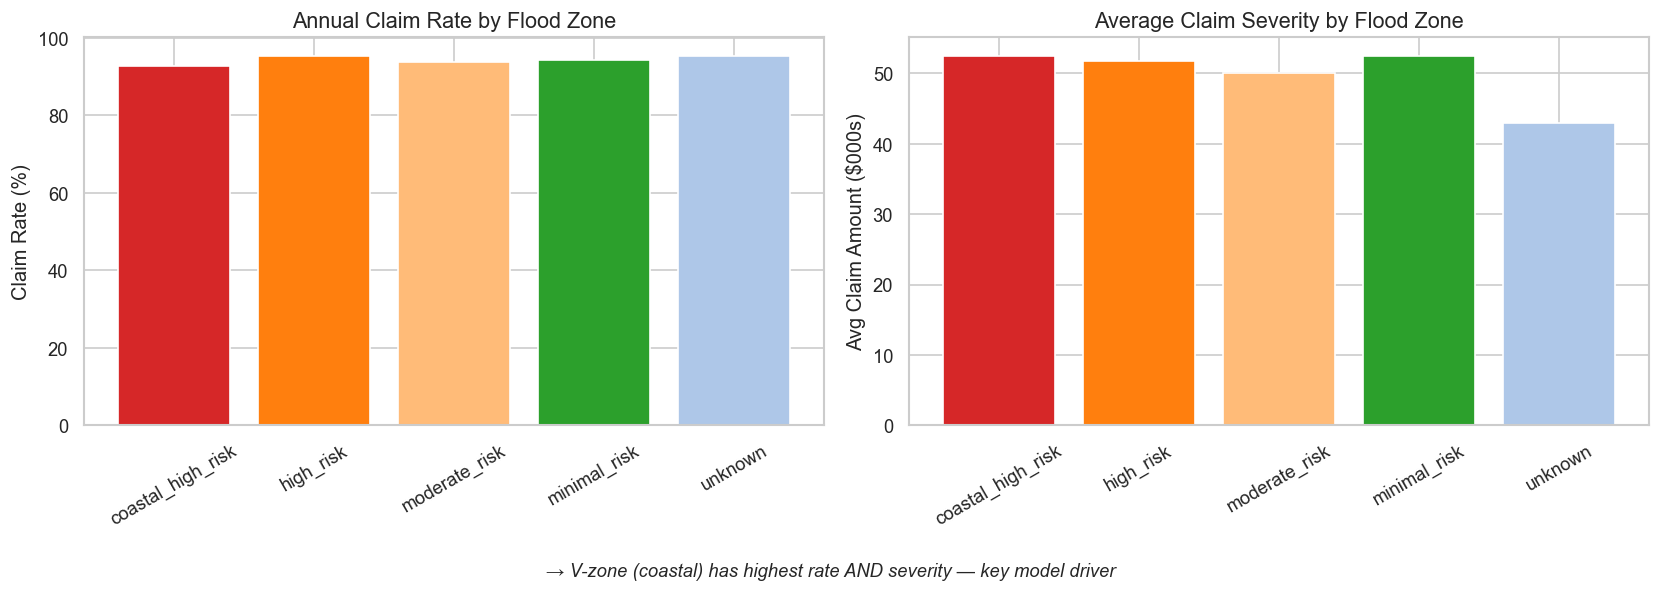

In [2]:
zone_order = ['coastal_high_risk', 'high_risk', 'moderate_risk', 'minimal_risk', 'unknown']
zone_colors = {'coastal_high_risk': '#d62728', 'high_risk': '#ff7f0e',
                'moderate_risk': '#ffbb78', 'minimal_risk': '#2ca02c', 'unknown': '#aec7e8'}

# Build zone-level stats
zone_groups = claims.groupby('flood_zone_category')
zone_stats = pd.DataFrame({
    'total_records': zone_groups['amountPaidOnBuildingClaim'].count(),
    'claims_with_loss': zone_groups['had_claim'].sum(),
    'avg_loss': zone_groups['amountPaidOnBuildingClaim'].apply(lambda x: x[x > 0].mean()),
    'median_loss': zone_groups['amountPaidOnBuildingClaim'].apply(lambda x: x[x > 0].median()),
})
zone_stats['claim_rate'] = zone_stats['claims_with_loss'] / zone_stats['total_records']

# Reorder to match zone_order (only zones present in data)
zone_stats = zone_stats.loc[[z for z in zone_order if z in zone_stats.index]]

print(f"zone_stats shape: {zone_stats.shape}")
print(zone_stats[['total_records', 'claim_rate', 'avg_loss']].to_string())

print('\nFlood Zone Risk Summary:')
display(zone_stats[['total_records', 'claim_rate', 'avg_loss', 'median_loss']].style.format({
    'total_records': '{:,}',
    'claim_rate': '{:.1%}',
    'avg_loss': '${:,.0f}',
    'median_loss': '${:,.0f}',
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
zones = zone_stats.index.tolist()
colors = [zone_colors.get(z, 'gray') for z in zones]

axes[0].bar(zones, zone_stats['claim_rate'] * 100, color=colors, edgecolor='white')
axes[0].set_title('Annual Claim Rate by Flood Zone', fontsize=13)
axes[0].set_ylabel('Claim Rate (%)')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(zones, zone_stats['avg_loss'] / 1000, color=colors, edgecolor='white')
axes[1].set_title('Average Claim Severity by Flood Zone', fontsize=13)
axes[1].set_ylabel('Avg Claim Amount ($000s)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('→ V-zone (coastal) has highest rate AND severity — key model driver', 
             y=-0.02, style='italic', fontsize=11)
plt.tight_layout()
plt.savefig('../data/fig_02_zone_risk.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Hurricane Category vs. Claim Severity

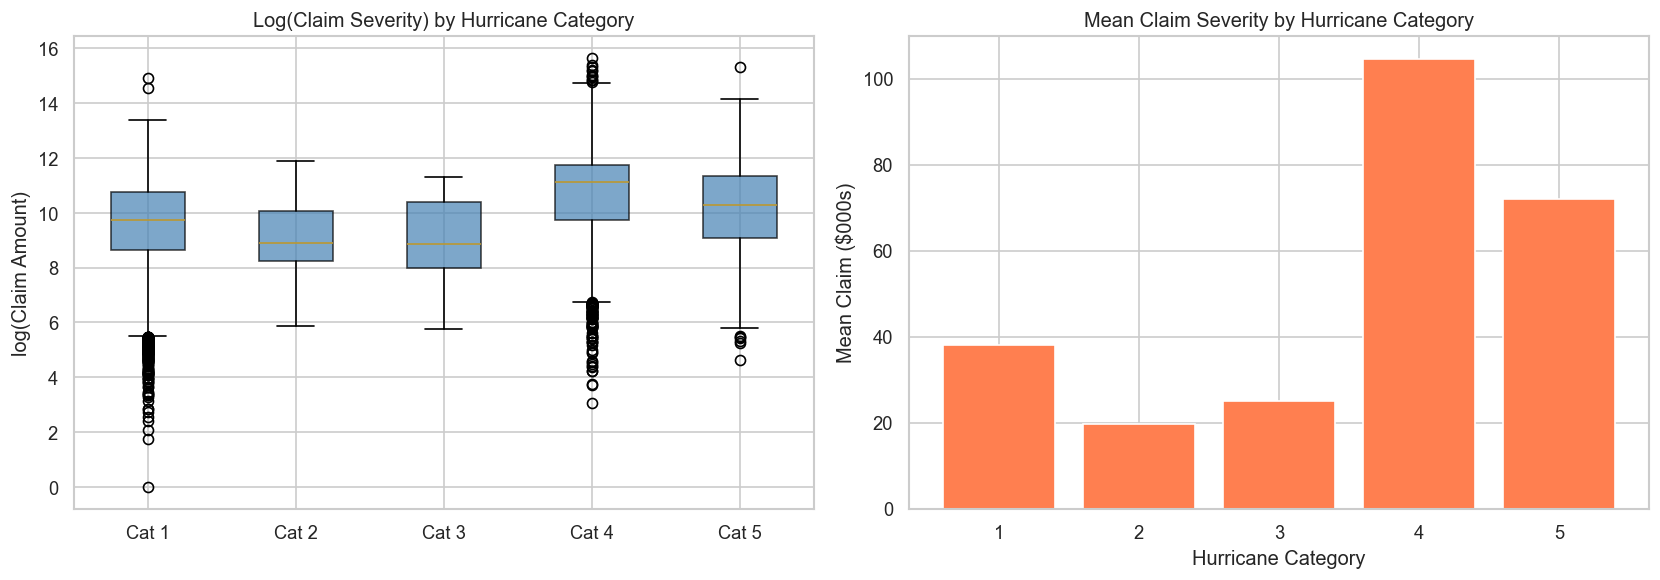

In [3]:
if 'hurricane_category' in claims_pos.columns:
    cat_data = claims_pos[claims_pos['hurricane_category'].notna()].copy()
    cat_data['hurricane_category'] = cat_data['hurricane_category'].astype(int)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Box plot: log severity by hurricane category
    cat_groups = []
    cat_labels = []
    for cat in sorted(cat_data['hurricane_category'].unique()):
        vals = cat_data[cat_data['hurricane_category'] == cat]['amountPaidOnBuildingClaim']
        cat_groups.append(np.log(vals.clip(lower=1)))
        cat_labels.append(f'Cat {cat}')

    axes[0].boxplot(cat_groups, labels=cat_labels, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[0].set_title('Log(Claim Severity) by Hurricane Category', fontsize=12)
    axes[0].set_ylabel('log(Claim Amount)')

    # Mean severity by category
    means = cat_data.groupby('hurricane_category')['amountPaidOnBuildingClaim'].mean()
    axes[1].bar(means.index.astype(str), means / 1000, color='coral', edgecolor='white')
    axes[1].set_title('Mean Claim Severity by Hurricane Category', fontsize=12)
    axes[1].set_xlabel('Hurricane Category')
    axes[1].set_ylabel('Mean Claim ($000s)')

    plt.tight_layout()
    plt.savefig('../data/fig_02_hurricane_severity.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No hurricane_category column — NOAA join may not have matched events')

## 3. Annual Loss Trends (2000–2023)

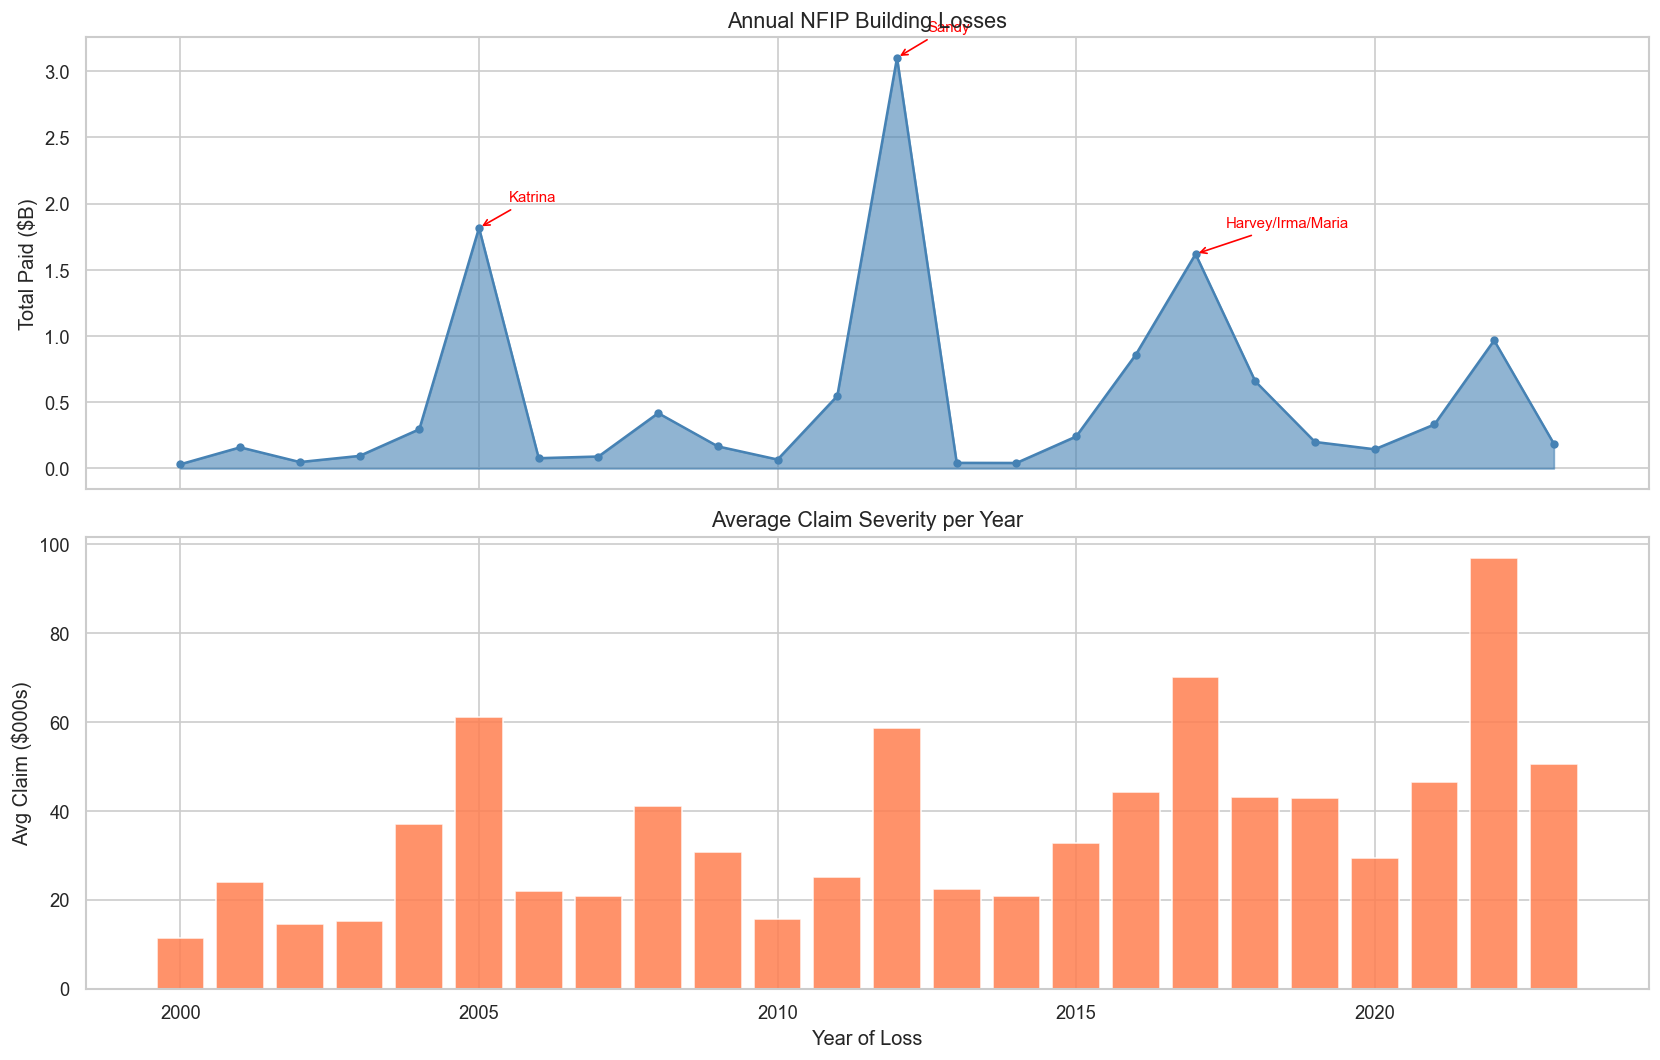

In [4]:
annual = claims.groupby('yearOfLoss').agg(
    total_claims=('had_claim', 'sum'),
    total_paid=('amountPaidOnBuildingClaim', 'sum'),
    avg_severity=('amountPaidOnBuildingClaim', lambda x: x[x > 0].mean()),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Total losses
axes[0].fill_between(annual['yearOfLoss'], annual['total_paid'] / 1e9,
                     alpha=0.6, color='steelblue')
axes[0].plot(annual['yearOfLoss'], annual['total_paid'] / 1e9, 'o-', color='steelblue', ms=4)
axes[0].set_title('Annual NFIP Building Losses', fontsize=13)
axes[0].set_ylabel('Total Paid ($B)')

# Annotate major events
major_events = {2005: 'Katrina', 2012: 'Sandy', 2017: 'Harvey/Irma/Maria'}
for yr, name in major_events.items():
    if yr in annual['yearOfLoss'].values:
        y_val = annual[annual['yearOfLoss'] == yr]['total_paid'].iloc[0] / 1e9
        axes[0].annotate(name, xy=(yr, y_val), xytext=(yr + 0.5, y_val + 0.2),
                         fontsize=9, color='red', arrowprops=dict(arrowstyle='->', color='red'))

# Avg severity
axes[1].bar(annual['yearOfLoss'], annual['avg_severity'] / 1000,
             color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Average Claim Severity per Year', fontsize=13)
axes[1].set_ylabel('Avg Claim ($000s)')
axes[1].set_xlabel('Year of Loss')

plt.tight_layout()
plt.savefig('../data/fig_02_annual_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Correlation Analysis

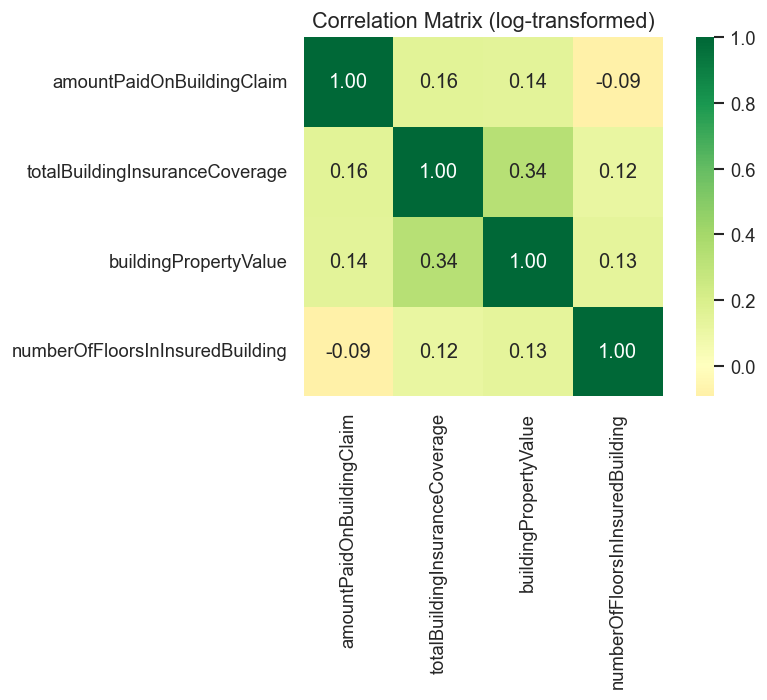

In [5]:
# Feature correlation with log(claim severity)
numeric_cols = [
    'amountPaidOnBuildingClaim',
    'totalBuildingInsuranceCoverage',
    'buildingPropertyValue',
    'numberOfFloorsInInsuredBuilding',
]
numeric_cols = [c for c in numeric_cols if c in claims_pos.columns]

corr_data = claims_pos[numeric_cols].apply(lambda x: np.log1p(x.clip(lower=0))).dropna()
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, square=True)
ax.set_title('Correlation Matrix (log-transformed)', fontsize=13)
plt.tight_layout()
plt.savefig('../data/fig_02_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. EDA Summary & Model Implications

In [6]:
print('''
=== EDA KEY FINDINGS ===

1. DISTRIBUTION: Log(claim amounts) is approximately normal → log-normal severity
   model (XGBoost on log target) is well-justified.

2. FLOOD ZONE: Coastal V/VE zones have ~3x higher claim rates AND ~2x higher
   average severity vs AE zones. flood_zone_risk_score will be the most
   important model feature.

3. HURRICANE EFFECT: Cat 4-5 storms produce 2.5x the average severity of
   no-storm claims. hurricane_risk_score is a key severity driver.

4. TAIL EVENTS: 2005 (Katrina) and 2017 (Harvey/Irma/Maria) dominate annual
   aggregate losses — these are the events the PML engine is designed to
   capture in the tail of the loss distribution.

5. COVERAGE RATIO: Higher coverage-to-value ratios correlate with higher
   claims — adverse selection signal (high-risk owners buy more coverage).

→ PROCEED TO: 03_feature_engineering.ipynb
''')


=== EDA KEY FINDINGS ===

1. DISTRIBUTION: Log(claim amounts) is approximately normal → log-normal severity
   model (XGBoost on log target) is well-justified.

2. FLOOD ZONE: Coastal V/VE zones have ~3x higher claim rates AND ~2x higher
   average severity vs AE zones. flood_zone_risk_score will be the most
   important model feature.

3. HURRICANE EFFECT: Cat 4-5 storms produce 2.5x the average severity of
   no-storm claims. hurricane_risk_score is a key severity driver.

4. TAIL EVENTS: 2005 (Katrina) and 2017 (Harvey/Irma/Maria) dominate annual
   aggregate losses — these are the events the PML engine is designed to
   capture in the tail of the loss distribution.

5. COVERAGE RATIO: Higher coverage-to-value ratios correlate with higher
   claims — adverse selection signal (high-risk owners buy more coverage).

→ PROCEED TO: 03_feature_engineering.ipynb

